# 8 · Baselines estadísticos: z-score multivariado y Mahalanobis

La propuesta del proyecto pedía, además de IForest/OCSVM, dos baselines puramente
**estadísticos** (sin aprendizaje, sin redes): **z-score multivariado** y **distancia de
Mahalanobis**. Cierran el checklist de baselines antes de pasar a los modelos de
reconstrucción (nb 2 en adelante).

Ambos son **deterministas** (no tienen semilla; `random_state` se guarda solo por
consistencia con la interfaz) y muy baratos de calcular: solo necesitan media (y,
en Mahalanobis, covarianza) del train normal.

- **Z-score multivariado** (`ZScoreDetector`): para cada feature calcula
  `z = (x − media_train) / desvío_train`; el score de una fila es el **promedio** (o el
  **máximo**) de `|z|` entre sus 54 features. Trata cada feature como independiente —
  **no ve correlaciones**.
- **Mahalanobis** (`MahalanobisDetector`): usa la **matriz de covarianza completa** del
  train (con encogimiento de Ledoit-Wolf para que la inversa sea estable con 54
  features) → la distancia contempla cómo varían las features **juntas**, no feature por
  feature. Es, en cierto sentido, "z-score con correlaciones".

**Referencia (nb 1 y nb 3, soja):** Isolation Forest ronda **PR-AUC ≈ 0.52**; el
seed-ensemble de VAEs ronda **≈ 0.64**. Estos dos baselines estadísticos deberían quedar
en ese rango o por debajo — son más simples que un IForest y muchísimo más simples que un
VAE.

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector, VAEDetector,
                        EnsembleDetector, ZScoreDetector, MahalanobisDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS
print("semillas:", SEEDS)

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 28683 -> 21418 filas (7265 duplicados espurios por lat/lon eliminados)
soja  train: (6377, 54) | test anómalas: 257
maíz  train: (8347, 54) | test anómalas: 349


## 8.1 · Z-score multivariado
Barato y sin hiperparámetros salvo la agregación (`mean` vs `max`). Ambos son
deterministas → una sola corrida (std = 0), igual que OCSVM en el nb 1:

In [3]:
filas_z = {}
for agg in ["mean", "max"]:
    z = ZScoreDetector(agg=agg).fit(ds.X_train)
    filas_z[f"ZScore ({agg})"] = [lab.metrics(z.score_samples(ds.X_test), ds.y_test)]
pd.DataFrame({k: lab.mean_std(v) for k, v in filas_z.items()}).T[["pr_auc", "roc_auc"]]

,pr_auc,roc_auc
ZScore (mean),0.559±nan,0.732±nan
ZScore (max),0.343±nan,0.640±nan


## 8.2 · Distancia de Mahalanobis
Con covarianza de Ledoit-Wolf (encogimiento automático, necesario porque 54 features con
pocas observaciones de train dejarían la covarianza empírica mal condicionada):

In [4]:
maha = MahalanobisDetector(shrinkage=None).fit(ds.X_train)
print("shrinkage resuelto (Ledoit-Wolf):", maha.get_config()["resolved_shrinkage"])
m_maha = lab.metrics(maha.score_samples(ds.X_test), ds.y_test)
m_maha

shrinkage resuelto (Ledoit-Wolf): 0.0031538325980423176


{'pr_auc': 0.37659538307329377,
 'roc_auc': 0.6542715026600942,
 'prec_at_k': 0.4163424124513619,
 'recall_at_contam': 0.14785992217898833}

## 8.3 · Comparación en soja y maíz, contra IForest y el seed-ensemble VAE

> La referencia de ensemble es **una réplica** (base=42, ×5 VAEs) por cultivo. El número
> oficial del VAE (≈ 0.64 en soja, seed-ensemble ×10) está en el nb 4.1; acá corremos una
> sola réplica más liviana (5 miembros, menos épocas) para que el "Run all" de este
> notebook cierre en máquinas con poca memoria — el punto pedagógico es ubicar a los
> baselines *debajo* del VAE, no reproducir su PR-AUC exacto.

In [5]:
def make_ensemble(base_seed, n=5):
    # Réplica liviana del ensemble del nb 4 (allá son 10 miembros y más épocas).
    miembros = [VAEDetector(hidden_dims=(128,64), latent_dim=24, beta=1.0, n_mc_samples=30,
                            score_mode="recon_prob", max_epochs=150, patience=20,
                            random_state=base_seed+i) for i in range(n)]
    return EnsembleDetector(miembros, normalize="zscore", combine="mean")

# IForest de referencia con pocas semillas (3) para no saturar memoria.
IFOREST_SEEDS = SEEDS[:3]

resultados = {}
for nombre, dset in [("soja", ds), ("maíz", dsm)]:
    resultados[nombre] = lab.leaderboard({
        "ZScore (mean)": [lab.metrics(ZScoreDetector(agg="mean").fit(dset.X_train)
                                      .score_samples(dset.X_test), dset.y_test)],
        "ZScore (max)": [lab.metrics(ZScoreDetector(agg="max").fit(dset.X_train)
                                     .score_samples(dset.X_test), dset.y_test)],
        "Mahalanobis (Ledoit-Wolf)": [lab.metrics(MahalanobisDetector(shrinkage=None)
                                      .fit(dset.X_train).score_samples(dset.X_test), dset.y_test)],
        "IForest (referencia)": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                                 random_state=s).fit(dset.X_train).score_samples(dset.X_test), dset.y_test)
                                 for s in IFOREST_SEEDS],
        "VAE seed-ensemble (referencia, 1 réplica ×5)": [lab.metrics(make_ensemble(42).fit(dset.X_train)
                                                      .score_samples(dset.X_test), dset.y_test)],
    })
    print(f"--- {nombre} ---")
    print(resultados[nombre][["modelo","pr_auc","pr_auc_std","roc_auc"]].round(3))

--- soja ---
                                         modelo  pr_auc  pr_auc_std  roc_auc
0  VAE seed-ensemble (referencia, 1 réplica ×5)   0.613       0.000    0.753
1                                 ZScore (mean)   0.559       0.000    0.732
2                          IForest (referencia)   0.513       0.014    0.693
3                     Mahalanobis (Ledoit-Wolf)   0.377       0.000    0.654
4                                  ZScore (max)   0.343       0.000    0.640
--- maíz ---
                                         modelo  pr_auc  pr_auc_std  roc_auc
0  VAE seed-ensemble (referencia, 1 réplica ×5)   0.533       0.000    0.683
1                                 ZScore (mean)   0.505       0.000    0.658
2                          IForest (referencia)   0.492       0.018    0.663
3                     Mahalanobis (Ledoit-Wolf)   0.331       0.000    0.546
4                                  ZScore (max)   0.298       0.000    0.519


### Gráfico comparativo (PR-AUC, ambos cultivos)

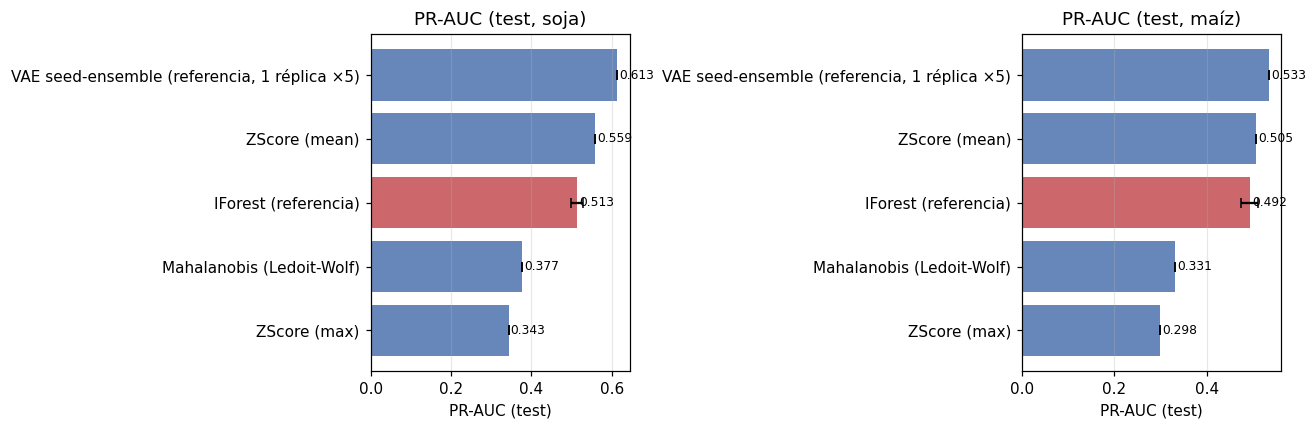

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nombre, lb) in zip(axs, resultados.items()):
    lab.plot_leaderboard(lb, ax=ax, titulo=f"PR-AUC (test, {nombre})")
plt.tight_layout(); plt.show()

## 8.4 · Interpretación
**La sorpresa es el z-score con `agg='mean'`: queda a la par del Isolation Forest**
(mirar las tablas de 8.3 — en soja incluso lo supera levemente en PR-AUC), pese a no
tener ningún aprendizaje. Tiene sentido con lo que sabemos del problema (nb 5): la señal
detectable es la **sequía**, que corre *muchas* features climáticas a la vez en la misma
dirección → promediar |z| entre las 54 features es casi un "índice de sequía" hecho a
mano. El `agg='max'`, en cambio, se hunde: **una sola feature rara no es anomalía de
rinde**.

**Mahalanobis queda por debajo del z-score medio.** Contra la intuición, incorporar la
covarianza acá *lastima*: la distancia de Mahalanobis **des-pondera justamente las
direcciones de mayor varianza** — las que las features climáticas correlacionadas
comparten, donde vive la firma de sequía — y realza desviaciones en direcciones raras
pero irrelevantes para el rinde. Es la misma lección de Cartography (nb 5): *rareza
climática ≠ anomalía de rinde*.

Ninguno de los dos alcanza al **seed-ensemble VAE** (≈ 0.64 en soja), que sigue siendo el
modelo final. Pero el z-score medio queda como **piso barato y sin aprendizaje** que
cualquier modelo debe superar con claridad — y de hecho AE/DAE con MSE (nb 2) no lo
superaban, lo que refuerza la conclusión de esa etapa: el salto real lo da el *score*
probabilístico, no la arquitectura. Con esto, el **checklist de baselines de la propuesta
queda cerrado**: IForest, OCSVM, z-score multivariado y Mahalanobis.